<a href="https://colab.research.google.com/github/Chathuranga630/sionna/blob/main/Spoofed_Traffic_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sionna

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.1/562.1 kB 42.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.7/16.7 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 92.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.7/271.7 kB 29.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.3/217.3 kB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 108.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4

In [1]:
pip show sionna


Name: sionna
Version: 2.0.1
Summary: Sionna - A hardware-accelerated differentiable open-source library for research on communication systems
Home-page: 
Author: 
Author-email: The Sionna contributors <sionna@nvidia.com>
License: Apache-2.0
Location: /usr/local/lib/python3.13/dist-packages
Requires: h5py, importlib-resources, matplotlib, numpy, scipy, sionna-rt, torch
Required-by: 


In [2]:
import tensorflow as tf
import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

TensorFlow: 2.20.0
Sionna: 2.0.1


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation area (meters)
AREA_X = 1000
AREA_Y = 1000

print("Simulation Area:", AREA_X, "x", AREA_Y, "meters")

Simulation Area: 1000 x 1000 meters


In [4]:
bs_positions = np.array([
    [250,250],
    [750,250],
    [500,750]
])

print(bs_positions)

[[250 250]
 [750 250]
 [500 750]]


In [5]:
num_users = 30

user_positions = np.random.rand(num_users,2)

user_positions[:,0] *= AREA_X
user_positions[:,1] *= AREA_Y

print(user_positions)

[[236.38086156 448.10329518]
 [493.28587206 987.25415384]
 [838.03081093 769.5388482 ]
 [712.00373044 911.55103821]
 [ 84.76948735 194.94816026]
 [196.1406463  919.43110051]
 [379.46506326 395.10385048]
 [365.55371583  14.22479541]
 [729.55168344 731.96016146]
 [270.4398998  645.14280995]
 [318.75413568 333.65884857]
 [983.13852212 946.3264824 ]
 [705.8255508  802.31160765]
 [996.42815396 967.75431065]
 [425.42900092 210.54082256]
 [415.13076196 918.30580836]
 [981.5521114  341.44165457]
 [360.20721386 810.33233451]
 [370.16216393 916.61477602]
 [284.84318158 516.62587692]
 [ 89.48997529 256.28945345]
 [461.5173959  275.91115524]
 [922.41613108 297.38674259]
 [272.88377357 721.16261871]
 [316.77752439  97.59396119]
 [489.86791068 891.63294755]
 [284.22981829 476.19914662]
 [527.77916094 310.70418579]
 [795.91557949 108.04817363]
 [728.63678815 701.83783492]]


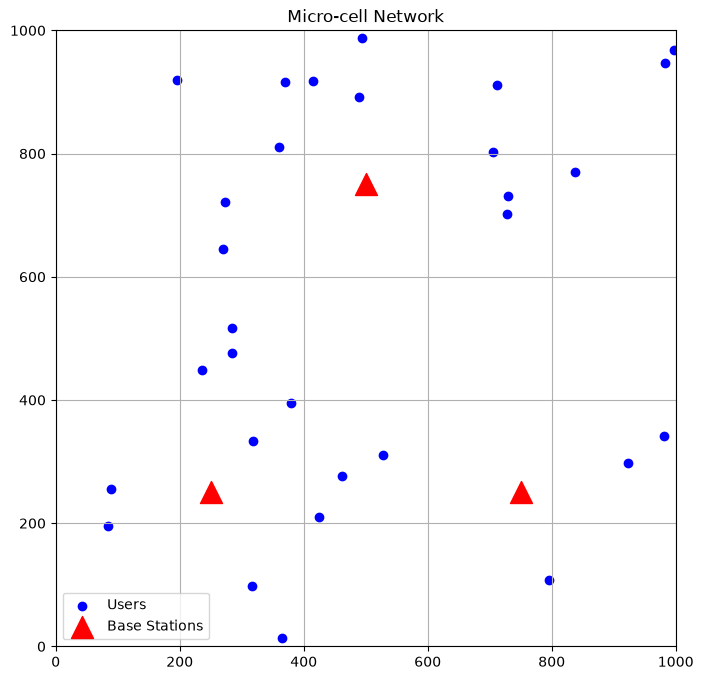

In [6]:
plt.figure(figsize=(8,8))

# Users
plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c='blue',
    label='Users'
)

# Base Stations
plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    c='red',
    s=250,
    marker='^',
    label='Base Stations'
)

plt.xlim(0,AREA_X)
plt.ylim(0,AREA_Y)

plt.grid(True)
plt.legend()

plt.title("Micro-cell Network")

plt.savefig("figures_network_layout_1.png", dpi=300, bbox_inches="tight")
plt.show()


In [7]:
import tensorflow as tf
import sionna
import numpy as np
import matplotlib.pyplot as plt


# Distance matrix
distance_matrix = np.zeros((len(user_positions), len(bs_positions)))

for i, user in enumerate(user_positions):

    for j, bs in enumerate(bs_positions):

        distance = np.linalg.norm(user-bs)

        distance_matrix[i,j] = distance

print(distance_matrix)

[[ 198.57088531  550.49935053  400.79504804]
 [ 776.35797342  780.67011653  237.34913741]
 [ 784.66607509  526.9440563   338.59503205]
 [ 806.90595679  662.64130015  266.54140329]
 [ 174.16034959  667.5045618   693.18029649]
 [ 671.59424381  868.84876821  347.90430387]
 [ 194.46421272  397.93374671  374.80654733]
 [ 262.56924485  450.98657686  747.95785644]
 [ 679.89367869  482.39375087  230.25944312]
 [ 395.67111312  621.38211268  252.37446366]
 [ 108.28635241  439.28555456  454.08150998]
 [1011.1195096   734.31882761  521.50447673]
 [ 716.11803825  554.07535038  212.36916362]
 [1035.53186309  758.87949341  542.08657228]
 [ 179.81201586  326.96079295  544.58887064]
 [ 688.40454824  747.50923745  188.49305742]
 [ 737.24491716  248.95372358  631.51592032]
 [ 571.06738226  682.57654606  152.25640757]
 [ 677.35825473  767.23662668  211.23055476]
 [ 268.8929258   536.15317211  317.42075836]
 [ 160.63320098  660.53996848  642.08144667]
 [ 213.09856107  289.64392077  475.64812998]
 [ 674.083

In [8]:
assignments = np.argmin(distance_matrix, axis=1)

print(assignments)

[0 2 2 2 0 2 0 0 2 2 0 2 2 2 0 2 1 2 2 0 0 0 1 2 0 2 0 1 1 2]


In [9]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments==bs)

    print(f"BS {bs+1} has {count} users")

BS 1 has 11 users
BS 2 has 4 users
BS 3 has 15 users


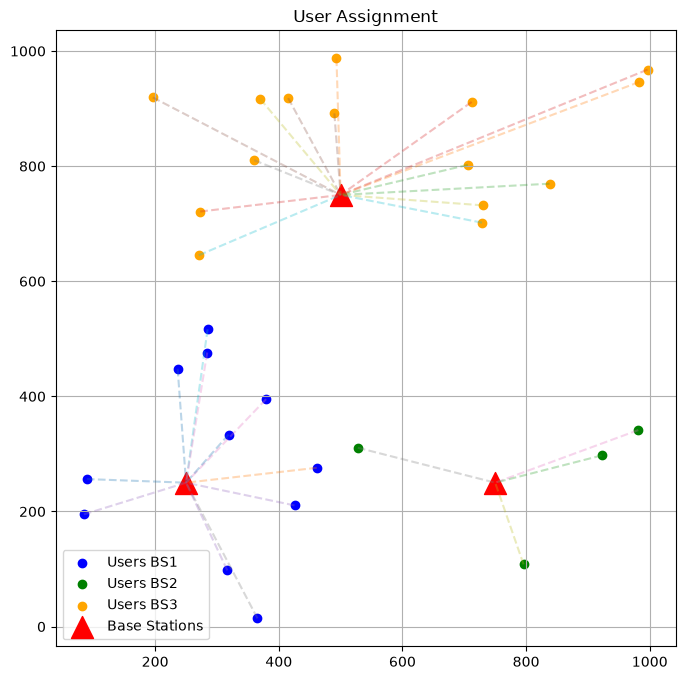

In [10]:
plt.figure(figsize=(8,8))

colors=['blue','green','orange']

# Draw users

for bs in range(3):

    idx = assignments==bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users BS{bs+1}'
    )

# Draw Base Stations

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=250,
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs=assignments[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3
    )

plt.grid()

plt.legend()

plt.title("User Assignment")

plt.savefig("figures_network_layout_2.png", dpi=300, bbox_inches="tight")
plt.show()

In [11]:
import pandas as pd

results = pd.DataFrame({
    "User": range(1, len(assignments)+1),
    "Assigned_BS": assignments
})

results.to_csv("user_assignment.csv", index=False)

In [12]:
# -------------------------------
# Network Parameters
# -------------------------------

frequency = 3500      # MHz (5G frequency)
tx_power = 30         # dBm (micro-cell transmit power)

print("Frequency:", frequency, "MHz")
print("Transmit Power:", tx_power, "dBm")

Frequency: 3500 MHz
Transmit Power: 30 dBm


In [13]:
distance_matrix
print(distance_matrix)

[[ 198.57088531  550.49935053  400.79504804]
 [ 776.35797342  780.67011653  237.34913741]
 [ 784.66607509  526.9440563   338.59503205]
 [ 806.90595679  662.64130015  266.54140329]
 [ 174.16034959  667.5045618   693.18029649]
 [ 671.59424381  868.84876821  347.90430387]
 [ 194.46421272  397.93374671  374.80654733]
 [ 262.56924485  450.98657686  747.95785644]
 [ 679.89367869  482.39375087  230.25944312]
 [ 395.67111312  621.38211268  252.37446366]
 [ 108.28635241  439.28555456  454.08150998]
 [1011.1195096   734.31882761  521.50447673]
 [ 716.11803825  554.07535038  212.36916362]
 [1035.53186309  758.87949341  542.08657228]
 [ 179.81201586  326.96079295  544.58887064]
 [ 688.40454824  747.50923745  188.49305742]
 [ 737.24491716  248.95372358  631.51592032]
 [ 571.06738226  682.57654606  152.25640757]
 [ 677.35825473  767.23662668  211.23055476]
 [ 268.8929258   536.15317211  317.42075836]
 [ 160.63320098  660.53996848  642.08144667]
 [ 213.09856107  289.64392077  475.64812998]
 [ 674.083

In [14]:
distance_km = distance_matrix / 1000

# Avoid log10(0)
distance_km[distance_km < 0.001] = 0.001

import numpy as np

path_loss = 32.44 \
            + 20*np.log10(frequency) \
            + 20*np.log10(distance_km)

print(path_loss)

[[ 89.27967233  98.13649711  95.37980783]
 [101.12260124 101.17071199  90.82911404]
 [101.21505841  97.75665109  93.91497252]
 [101.45781932  99.7469309   91.83665448]
 [ 88.14034664  99.81044565 100.13828508]
 [ 99.86350019 102.10024468  94.15055691]
 [ 89.09815468  95.31757631  94.79750426]
 [ 91.70623799  96.4046332  100.79890345]
 [ 99.97018095  96.98939435  90.56570989]
 [ 95.26804778  99.18853583  91.36226907]
 [ 84.01283538  96.17629933  96.46403725]
 [103.41741069 100.63905416  97.6665217 ]
 [100.42105315  98.19273748  89.86319002]
 [103.62463022 100.92481723  98.00273388]
 [ 88.41773509  93.61127445  98.04273612]
 [100.07823551 100.79369216  88.82726806]
 [100.67359663  91.24373341  99.32904696]
 [ 98.45510799 100.00438812  86.97287246]
 [ 99.93772944 101.01994743  89.81649568]
 [ 91.91294842  97.90713848  93.35406738]
 [ 87.43806716  99.71934291  99.47316331]
 [ 89.89297123  92.55864924  96.86707676]
 [ 99.89563857  88.36917108  99.15668278]
 [ 96.79501003  99.84995336  90.51

In [15]:
received_power = tx_power - path_loss

print(received_power)

[[-59.27967233 -68.13649711 -65.37980783]
 [-71.12260124 -71.17071199 -60.82911404]
 [-71.21505841 -67.75665109 -63.91497252]
 [-71.45781932 -69.7469309  -61.83665448]
 [-58.14034664 -69.81044565 -70.13828508]
 [-69.86350019 -72.10024468 -64.15055691]
 [-59.09815468 -65.31757631 -64.79750426]
 [-61.70623799 -66.4046332  -70.79890345]
 [-69.97018095 -66.98939435 -60.56570989]
 [-65.26804778 -69.18853583 -61.36226907]
 [-54.01283538 -66.17629933 -66.46403725]
 [-73.41741069 -70.63905416 -67.6665217 ]
 [-70.42105315 -68.19273748 -59.86319002]
 [-73.62463022 -70.92481723 -68.00273388]
 [-58.41773509 -63.61127445 -68.04273612]
 [-70.07823551 -70.79369216 -58.82726806]
 [-70.67359663 -61.24373341 -69.32904696]
 [-68.45510799 -70.00438812 -56.97287246]
 [-69.93772944 -71.01994743 -59.81649568]
 [-61.91294842 -67.90713848 -63.35406738]
 [-57.43806716 -69.71934291 -69.47316331]
 [-59.89297123 -62.55864924 -66.86707676]
 [-69.89563857 -58.36917108 -69.15668278]
 [-66.79501003 -69.84995336 -60.51

In [16]:
assignments_signal = np.argmax(received_power, axis=1)

print(assignments_signal)


[0 2 2 2 0 2 0 0 2 2 0 2 2 2 0 2 1 2 2 0 0 0 1 2 0 2 0 1 1 2]


In [17]:
for bs in range(len(bs_positions)):

    count = np.sum(assignments_signal == bs)

    print(f"BS {bs+1}: {count} users")

BS 1: 11 users
BS 2: 4 users
BS 3: 15 users


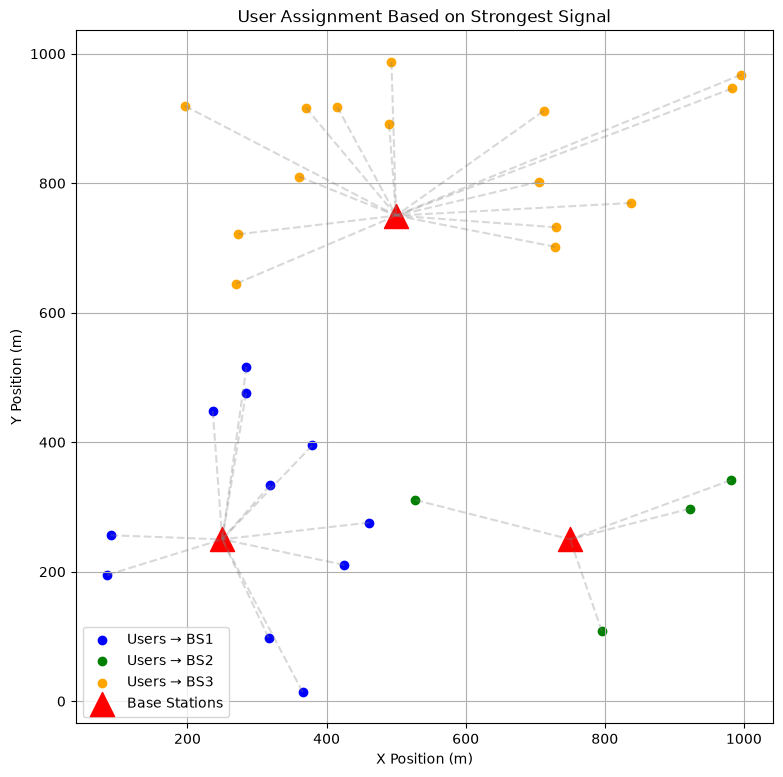

In [18]:
plt.figure(figsize=(9,9))

colors = ['blue','green','orange']

for bs in range(3):

    idx = assignments_signal == bs

    plt.scatter(
        user_positions[idx,0],
        user_positions[idx,1],
        color=colors[bs],
        label=f'Users → BS{bs+1}'
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    s=300,
    color='red',
    label='Base Stations'
)

# Draw association lines

for i,user in enumerate(user_positions):

    bs = assignments_signal[i]

    plt.plot(
        [user[0],bs_positions[bs][0]],
        [user[1],bs_positions[bs][1]],
        '--',
        alpha=0.3,
        color='gray'
    )

plt.title("User Assignment Based on Strongest Signal")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step4_user_assignment_signal.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [19]:
import pandas as pd

results = pd.DataFrame({
    "User": np.arange(1, len(user_positions)+1),
    "Assigned_BS": assignments_signal + 1,
    "Best_RSRP_dBm": np.max(received_power, axis=1)
})

print(results.head())

results.to_csv("step4_user_assignment.csv", index=False)

   User  Assigned_BS  Best_RSRP_dBm
0     1            1     -59.279672
1     2            3     -60.829114
2     3            3     -63.914973
3     4            3     -61.836654
4     5            1     -58.140347


In [20]:
#STEP 5 - SINR Calculation
# Convert dBm to mW

received_power_mW = 10 ** (received_power / 10)

print(received_power_mW)

[[1.18040969e-06 1.53585526e-07 2.89747180e-07]
 [7.72217921e-08 7.63710569e-08 8.26206478e-07]
 [7.55951892e-08 1.67623495e-07 4.05978232e-07]
 [7.14855179e-08 1.06000255e-07 6.55140656e-07]
 [1.53449450e-06 1.04461302e-07 9.68660281e-08]
 [1.03192939e-07 6.16560264e-08 3.84542467e-07]
 [1.23079162e-06 2.93928954e-07 3.31321466e-07]
 [6.75112581e-07 2.28842498e-07 8.31973809e-08]
 [1.00688971e-07 2.00014078e-07 8.77867581e-07]
 [2.97300214e-07 1.20544227e-07 7.30757184e-07]
 [3.96932319e-06 2.41195981e-07 2.25733635e-07]
 [4.55259410e-08 8.63166515e-08 1.71138543e-07]
 [9.07600413e-08 1.51609443e-07 1.03200309e-06]
 [4.34047219e-08 8.08198940e-08 1.58389582e-07]
 [1.43954913e-06 4.35384091e-07 1.56937376e-07]
 [9.82146898e-08 8.32972730e-08 1.31000572e-06]
 [8.56328380e-08 7.50977039e-07 1.16706570e-07]
 [1.42721434e-07 9.98990109e-08 2.00776442e-06]
 [1.01444161e-07 7.90688199e-08 1.04315881e-06]
 [6.43732088e-07 1.61914652e-07 4.61948181e-07]
 [1.80382036e-06 1.06675751e-07 1.128973

In [21]:
# Thermal Noise (Assume a simple fixed thermal noise power)
noise_dBm = -100

noise_mW = 10 ** (noise_dBm / 10)

print("Noise Power (mW):", noise_mW)

Noise Power (mW): 1e-10


In [22]:
# Calculate SINR
sinr = []

for i in range(len(user_positions)):

    serving_bs = assignments_signal[i]

    signal = received_power_mW[i, serving_bs]

    interference = np.sum(received_power_mW[i]) - signal

    sinr_linear = signal / (interference + noise_mW)

    sinr.append(sinr_linear)

sinr = np.array(sinr)

# Convert SINR to dB
sinr_dB = 10 * np.log10(sinr)

print(sinr_dB)

[ 4.25205046  7.30434935  2.22327289  5.66926381  8.81846939  3.67594713
  2.94061086  3.35026943  4.65146776  2.4265454   9.2937204   1.12962817
  6.29023909  1.05169486  3.85595704  8.58128741  5.69331601  9.17606395
  7.61601471  0.13546436  9.14416444  1.29531865  8.12905225  4.5317568
  7.17545007 10.70202779  2.03423441  0.31330101  9.40998554  4.05668196]


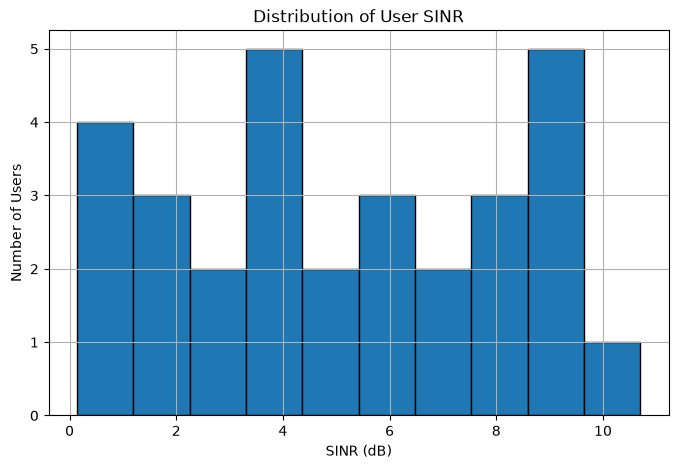

In [23]:
# Plot SINR Distribution
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=10,
         edgecolor='black')

plt.xlabel("SINR (dB)")
plt.ylabel("Number of Users")
plt.title("Distribution of User SINR")

plt.grid(True)

plt.savefig("figures_step5_sinr_histogram.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

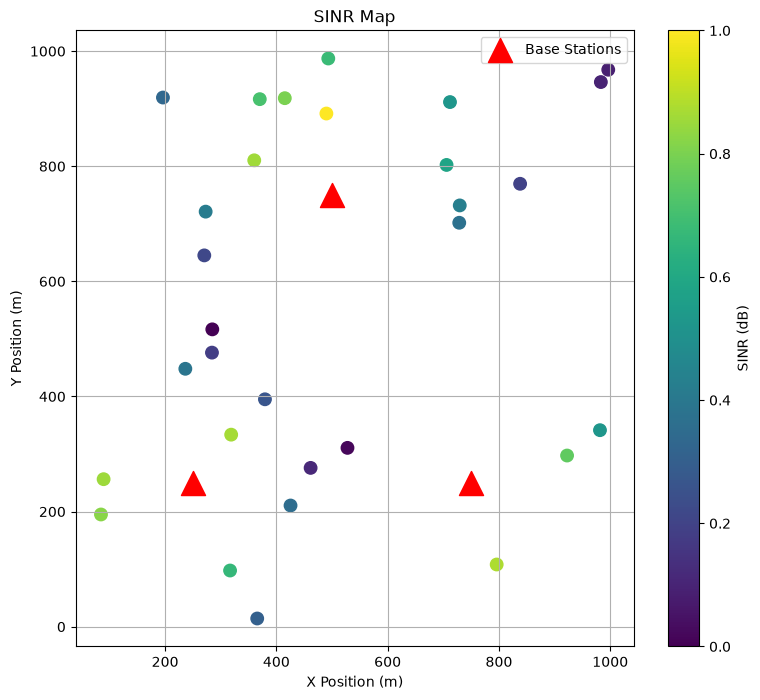

In [24]:
# Network Visualization
plt.figure(figsize=(9,8))

plt.scatter(
    user_positions[:,0],
    user_positions[:,1],
    c=sinr_dB,
    cmap='viridis',
    s=80
)

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker='^',
    color='red',
    s=300,
    label='Base Stations'
)

plt.colorbar(label="SINR (dB)")

plt.title("SINR Map")

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")

plt.grid(True)

plt.legend()

plt.savefig("figures_step5_sinr_map.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

In [25]:
# Statistics
print("Average SINR :", np.mean(sinr_dB))

print("Maximum SINR :", np.max(sinr_dB))

print("Minimum SINR :", np.min(sinr_dB))

Average SINR : 5.164253513587721
Maximum SINR : 10.702027792885378
Minimum SINR : 0.13546436304820103


In [26]:
# Save Results
results["SINR_dB"] = sinr_dB

results.to_csv(
    "results_step5_sinr_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm   SINR_dB
0     1            1     -59.279672  4.252050
1     2            3     -60.829114  7.304349
2     3            3     -63.914973  2.223273
3     4            3     -61.836654  5.669264
4     5            1     -58.140347  8.818469


In [27]:
#====================================================
# STEP 6 - QoS Analysis
#====================================================

# Spectral Efficiency (bits/s/Hz)

spectral_efficiency = np.log2(1 + sinr)

print(spectral_efficiency)


[1.87262453 2.6725835  1.41603125 2.22932661 3.10737063 1.73607726
 1.56957037 1.66122637 1.97026953 1.45862103 3.24778816 1.1997937
 2.39402523 1.18523236 1.7781837  3.03794667 2.23561635 3.21286832
 2.76036106 1.02267559 3.20341818 1.23113105 2.90686719 1.94075583
 2.63656472 3.67293021 1.37708815 1.05297648 3.28239304 1.82573891]


In [28]:
# Bandwidth per user

bandwidth = 20e6      # 20 MHz

throughput = bandwidth * spectral_efficiency

throughput_Mbps = throughput / 1e6

print(throughput_Mbps)

[37.45249067 53.45166993 28.32062501 44.58653213 62.14741263 34.7215452
 31.39140744 33.22452739 39.40539055 29.17242058 64.95576315 23.99587399
 47.88050469 23.70464723 35.56367405 60.75893337 44.71232707 64.25736646
 55.20722125 20.45351183 64.06836355 24.62262103 58.13734371 38.81511666
 52.73129446 73.45860421 27.54176296 21.05952957 65.64786085 36.51477815]


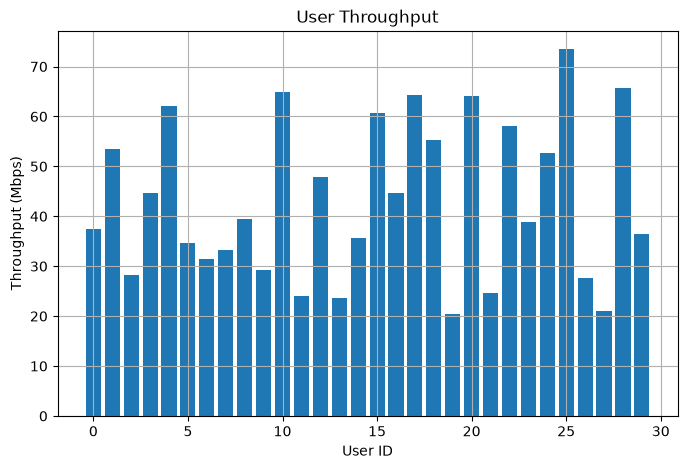

In [29]:
# Plot Throughput

plt.figure(figsize=(8,5))

plt.bar(range(len(throughput_Mbps)),
        throughput_Mbps)

plt.xlabel("User ID")
plt.ylabel("Throughput (Mbps)")
plt.title("User Throughput")

plt.grid(True)

plt.savefig(
    "figures_step6_throughput.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [30]:
# Average Throughput
print("Average Throughput:")

print(np.mean(throughput_Mbps),"Mbps")

Average Throughput:
43.265370659023134 Mbps


In [31]:
# Packet Error Rate (PER)
packet_error_rate = np.exp(-sinr)

print(packet_error_rate)

[6.98097512e-02 4.62768334e-03 1.88528867e-01 2.49932229e-02
 4.91472420e-04 9.71711446e-02 1.39713259e-01 1.14996602e-01
 5.40193389e-02 1.74042575e-01 2.03655157e-04 2.73331970e-01
 1.41758078e-02 2.79710492e-01 8.80420390e-02 7.36786242e-04
 2.44863713e-02 2.55593744e-04 3.10215568e-03 3.56406486e-01
 2.71544225e-04 2.59886680e-01 1.50362217e-03 5.84801879e-02
 5.41549053e-03 7.85419620e-06 2.02414865e-01 3.41363958e-01
 1.61713449e-04 7.84820611e-02]


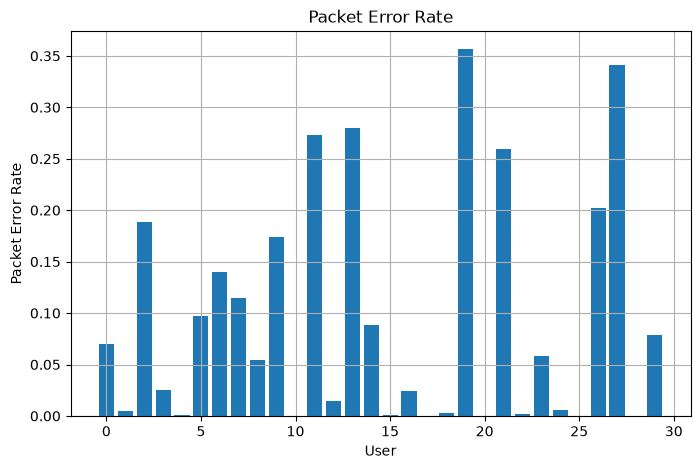

In [32]:
# Plot PER
plt.figure(figsize=(8,5))

plt.bar(range(len(packet_error_rate)),
        packet_error_rate)

plt.xlabel("User")

plt.ylabel("Packet Error Rate")

plt.title("Packet Error Rate")

plt.grid(True)

plt.savefig(
    "figures_step6_packet_error_rate.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [33]:
# Latency Model
latency = 100/(sinr+1)

print(latency)

[27.30761963 15.68455501 37.4741783  21.32582403 11.60347931 30.01847808
 33.69087091 31.61702723 25.52053489 36.3840733  10.52733262 43.5337529
 19.02508449 43.97537052 29.15502162 12.17550343 21.23305177 10.78525115
 14.75871415 49.22026766 10.85613012 42.59833504 13.33354969 26.04799381
 16.08106965  7.84039304 38.49950633 48.19727618 10.27782543 28.20965823]


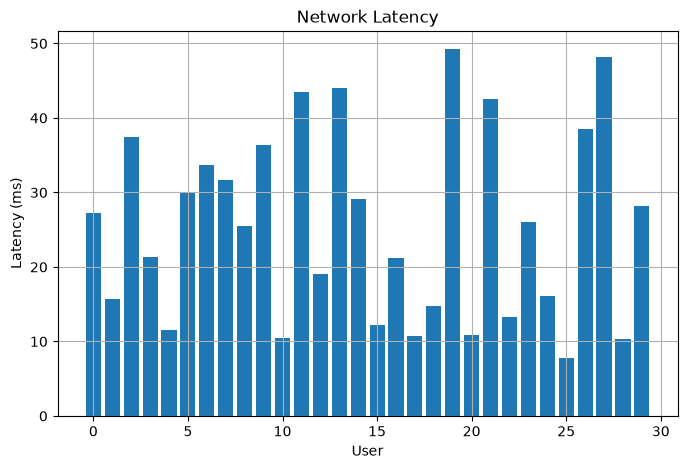

In [34]:
# Plot Latency
plt.figure(figsize=(8,5))

plt.bar(range(len(latency)),
        latency)

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Network Latency")

plt.grid(True)

plt.savefig(
    "figures_step6_latency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [35]:
# QoS Summary
print("========== QoS SUMMARY ==========")

print("Average SINR:",
      np.mean(sinr_dB),
      "dB")

print("Average Throughput:",
      np.mean(throughput_Mbps),
      "Mbps")

print("Average Latency:",
      np.mean(latency),
      "ms")

print("Average PER:",
      np.mean(packet_error_rate))

========== QoS SUMMARY ==========
Average SINR: 5.164253513587721 dB
Average Throughput: 43.265370659023134 Mbps
Average Latency: 25.565257617151698 ms
Average PER: 0.09522777498853005


In [36]:
# Save Results
results["SINR_dB"] = sinr_dB
results["Spectral_Efficiency"] = spectral_efficiency
results["Throughput_Mbps"] = throughput_Mbps
results["Latency_ms"] = latency
results["PER"] = packet_error_rate

results.to_csv(
    "results_step6_qos_results.csv",
    index=False
)

print(results.head())

   User  Assigned_BS  Best_RSRP_dBm   SINR_dB  Spectral_Efficiency  \
0     1            1     -59.279672  4.252050             1.872625   
1     2            3     -60.829114  7.304349             2.672583   
2     3            3     -63.914973  2.223273             1.416031   
3     4            3     -61.836654  5.669264             2.229327   
4     5            1     -58.140347  8.818469             3.107371   

   Throughput_Mbps  Latency_ms       PER  
0        37.452491   27.307620  0.069810  
1        53.451670   15.684555  0.004628  
2        28.320625   37.474178  0.188529  
3        44.586532   21.325824  0.024993  
4        62.147413   11.603479  0.000491  


In [37]:
# Step 7
# Save normal network results

normal_throughput = throughput_Mbps.copy()
normal_latency = latency.copy()
normal_per = packet_error_rate.copy()
normal_assignments = assignments_signal.copy()

In [38]:
# Number of users connected to each BS

cell_load = np.zeros(len(bs_positions), dtype=int)

for bs in assignments_signal:
    cell_load[bs] += 1

print("Current Cell Load")

for i, load in enumerate(cell_load):
    print(f"BS{i+1}: {load} users")

Current Cell Load
BS1: 11 users
BS2: 4 users
BS3: 15 users


In [39]:
#----------------------------------------
# Spoofed Traffic Attack
#----------------------------------------

target_bs = 1      # BS2 (index starts from 0)

spoofed_users = 20

print("Attack Target : BS", target_bs+1)
print("Fake Users :", spoofed_users)

Attack Target : BS 2
Fake Users : 20


In [40]:
# Increase Cell Load
attack_cell_load = cell_load.copy()

attack_cell_load[target_bs] += spoofed_users

print("Cell Load After Attack")

for i, load in enumerate(attack_cell_load):
    print(f"BS{i+1}: {load} users")

Cell Load After Attack
BS1: 11 users
BS2: 24 users
BS3: 15 users


In [41]:
# Available Bandwidth Per Cell
total_bandwidth = 20e6      #20 MHz

bandwidth_per_bs = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):
    bandwidth_per_bs[i] = total_bandwidth / attack_cell_load[i]

print(bandwidth_per_bs)

[1818181.81818182  833333.33333333 1333333.33333333]


In [42]:
# Calculate New Throughput
attack_throughput = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    attack_bandwidth = bandwidth_per_bs[bs]

    attack_throughput[i] = (
        attack_bandwidth
        * spectral_efficiency[i]
        / 1e6
    )

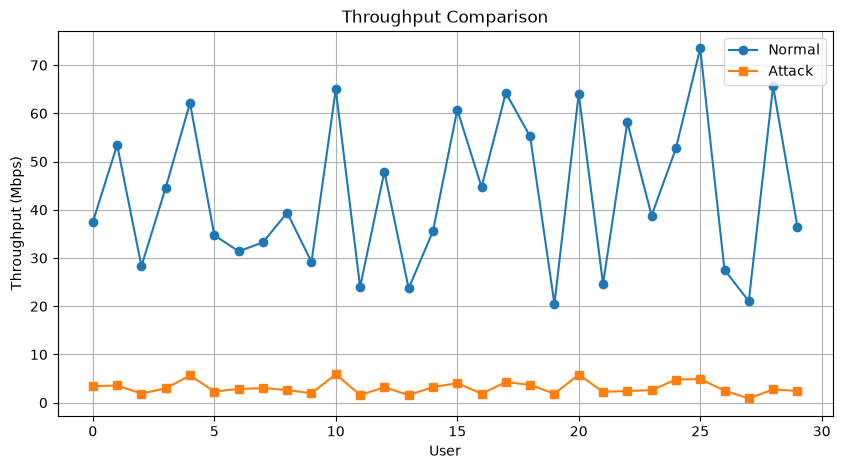

In [43]:
# Plot Throughput Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_throughput,
         marker='o',
         label="Normal")

plt.plot(attack_throughput,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Throughput (Mbps)")

plt.title("Throughput Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_throughput_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [44]:
# New Latency
attack_latency = np.zeros(len(user_positions))

for i in range(len(user_positions)):

    bs = assignments_signal[i]

    load_factor = attack_cell_load[bs] / cell_load[bs]

    attack_latency[i] = latency[i] * load_factor

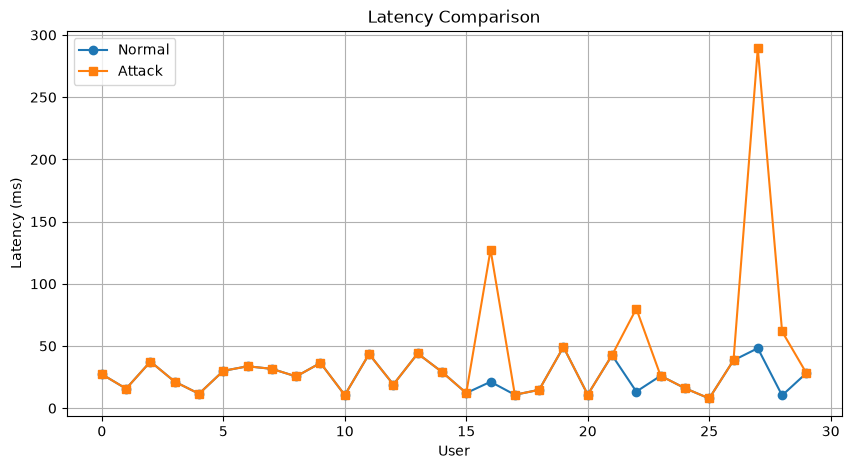

In [45]:
# Plot Latency Comparison
plt.figure(figsize=(10,5))

plt.plot(normal_latency,
         marker='o',
         label="Normal")

plt.plot(attack_latency,
         marker='s',
         label="Attack")

plt.xlabel("User")

plt.ylabel("Latency (ms)")

plt.title("Latency Comparison")

plt.grid(True)

plt.legend()

plt.savefig(
    "figures_step7_latency_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [46]:
# QoS Comparison
print("========== NORMAL ==========")

print("Average Throughput:",
      np.mean(normal_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(normal_latency),
      "ms")

print("\n========== ATTACK ==========")

print("Average Throughput:",
      np.mean(attack_throughput),
      "Mbps")

print("Average Latency:",
      np.mean(attack_latency),
      "ms")

========== NORMAL ==========
Average Throughput: 43.265370659023134 Mbps
Average Latency: 25.565257617151698 ms

========== ATTACK ==========
Average Throughput: 3.0933860114340233 Mbps
Average Latency: 41.07220812786225 ms


In [47]:
# Save Results
attack_results = results.copy()

attack_results["Attack_Throughput_Mbps"] = attack_throughput
attack_results["Attack_Latency_ms"] = attack_latency

attack_results.to_csv(
    "results_step7_attack_results.csv",
    index=False
)

In [48]:
# ====================================================
# STEP 7A - Legitimate Traffic Generation
# ====================================================

# Simulation Parameters
import numpy as np

simulation_time = 10          # seconds

packet_size = 1500            # Bytes

time_step = 1                 # second

# Legitimate Traffic
np.random.seed(42)

traffic_rate = np.random.randint(5,16,size=len(user_positions))

print(traffic_rate)

# Total Legitimate Packets
legitimate_packets = traffic_rate * simulation_time

print(legitimate_packets)

[11  8 15 12  9 11 14  7 11 15 15 12  9  8 12 12  7 10  9  6 12 10  6  9
  5 14 10 13  5 15]
[110  80 150 120  90 110 140  70 110 150 150 120  90  80 120 120  70 100
  90  60 120 100  60  90  50 140 100 130  50 150]


In [49]:
# Spoofed Traffic
attack_levels = {
    "Normal":0,
    "Low":50,
    "Medium":200,
    "High":500
}

target_bs = 1 # Suppose the attacker targets BS2

spoofed_packets = attack_levels["Medium"] * simulation_time

print(spoofed_packets)

2000


In [50]:
# Base Station Load
bs_packets = np.zeros(len(bs_positions))

for i,bs in enumerate(assignments_signal):

    bs_packets[bs] += legitimate_packets[i]

print(bs_packets)

# Inject Attack
attack_packets = bs_packets.copy()

attack_packets[target_bs] += spoofed_packets

print(attack_packets)

[1110.  310. 1700.]
[1110. 2310. 1700.]


In [51]:
# Queue Model
bs_capacity = 2000      # packets

queue = np.maximum(
    attack_packets-bs_capacity,
    0
)

print(queue)

[  0. 310.   0.]


In [52]:
# Queue Delay
queue_delay = queue / bs_capacity

print(queue_delay)

[0.    0.155 0.   ]


In [53]:
# User Latency
attack_latency = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    attack_latency[i] = latency[i] + queue_delay[bs]*1000

In [54]:
# Throughput Reduction
bs_capacity_Mbps = 1000

attack_throughput = np.zeros(len(user_positions))

for i,bs in enumerate(assignments_signal):

    load = attack_packets[bs]

    attack_throughput[i] = (
        throughput_Mbps[i]
        *
        bs_capacity
        /
        load
    )

In [55]:
# Packet Loss
packet_loss = np.zeros(len(bs_positions))

for i in range(len(bs_positions)):

    if attack_packets[i] > bs_capacity:

        packet_loss[i] = (
            attack_packets[i]-bs_capacity
        ) / attack_packets[i]
packet_loss1 = packet_loss*100
print(packet_loss1, "%")

[ 0.         13.41991342  0.        ] %


In [56]:
# Visulaization --- do later Base Station Queue Length vs Attack Level
# Throughput vs Attack Level
# Latency vs Attack Level
# Packet Loss vs Attack Level
# Cell Load vs Attack Level
# User Assignment Map
# QoS Heat Map

In [57]:
# ====================================================
# STEP 8 - Impact Assessment
# ====================================================

attack_levels = {
    "Normal": 0,
    "Low": 50,
    "Medium": 200,
    "High": 500
}

bs_capacity = 2000          # packets
simulation_time = 10        # seconds
target_bs = 1               # BS2

# Create Lists to Store Results
average_throughput = []
average_latency = []
average_packet_loss = []
average_queue = []

# Run All Attack Scenarios
for attack_name, attack_rate in attack_levels.items():

    spoofed_packets = attack_rate * simulation_time

    attack_packets = bs_packets.copy()

    attack_packets[target_bs] += spoofed_packets

    queue = np.maximum(attack_packets-bs_capacity,0)

    queue_delay = queue/bs_capacity

    attack_latency = np.zeros(len(user_positions))

    attack_throughput = np.zeros(len(user_positions))

    for i,bs in enumerate(assignments_signal):

        attack_latency[i] = latency[i] + queue_delay[bs]*1000

        attack_throughput[i] = (
            throughput_Mbps[i]
            *
            bs_capacity
            /
            attack_packets[bs]
        )

    packet_loss = np.zeros(len(bs_positions))

    for bs in range(len(bs_positions)):

        if attack_packets[bs] > bs_capacity:

            packet_loss[bs] = (
                attack_packets[bs]-bs_capacity
            )/attack_packets[bs]

    average_throughput.append(np.mean(attack_throughput))

    average_latency.append(np.mean(attack_latency))

    average_packet_loss.append(np.mean(packet_loss))

    average_queue.append(np.mean(queue))

# Display Results
import pandas as pd

impact_results = pd.DataFrame({

    "Attack_Level": attack_levels.keys(),

    "Avg_Throughput_Mbps": average_throughput,

    "Avg_Latency_ms": average_latency,

    "Avg_Queue_Packets": average_queue,

    "Avg_Packet_Loss": average_packet_loss

})

print(impact_results)


  Attack_Level  Avg_Throughput_Mbps  Avg_Latency_ms  Avg_Queue_Packets  \
0       Normal            93.698317       25.565258           0.000000   
1          Low            68.534761       25.565258           0.000000   
2       Medium            58.403979       46.231924         103.333333   
3         High            55.313232      246.231924        1103.333333   

   Avg_Packet_Loss  
0         0.000000  
1         0.000000  
2         0.044733  
3         0.207784  


In [58]:
# Save Results
impact_results.to_csv(
    "results_step8_impact_assessment.csv",
    index=False
)

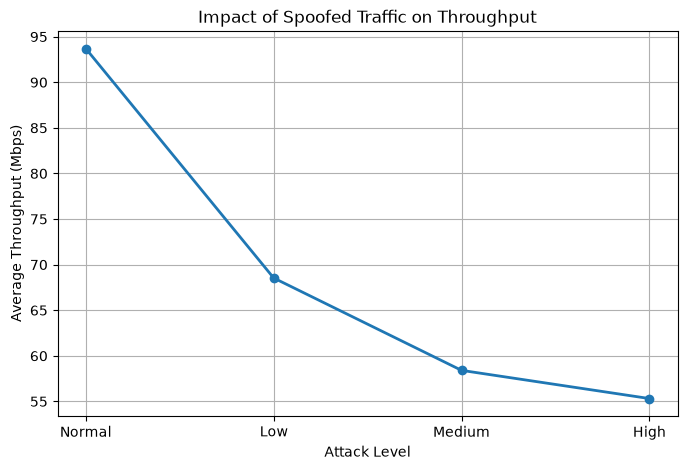

In [59]:
# Throughput vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Throughput_Mbps"],
    marker='o',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Throughput (Mbps)")

plt.title("Impact of Spoofed Traffic on Throughput")

plt.grid(True)

plt.savefig(
    "figures_step8_throughput_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

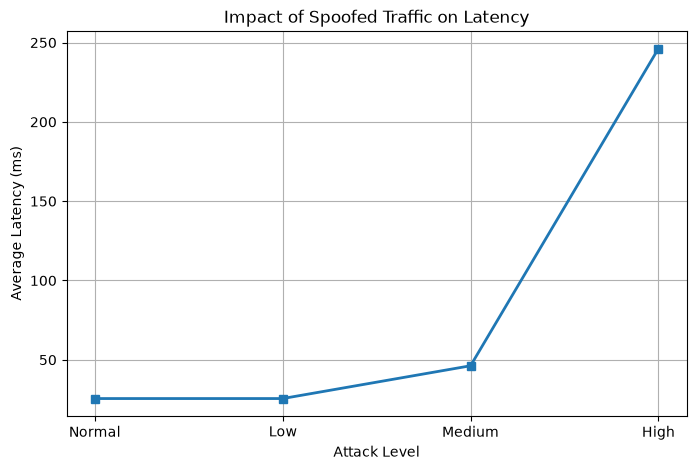

In [60]:
#Latency vs Attack Level
plt.figure(figsize=(8,5))

plt.plot(
    impact_results["Attack_Level"],
    impact_results["Avg_Latency_ms"],
    marker='s',
    linewidth=2
)

plt.xlabel("Attack Level")

plt.ylabel("Average Latency (ms)")

plt.title("Impact of Spoofed Traffic on Latency")

plt.grid(True)

plt.savefig(
    "figures_step8_latency_vs_attack.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

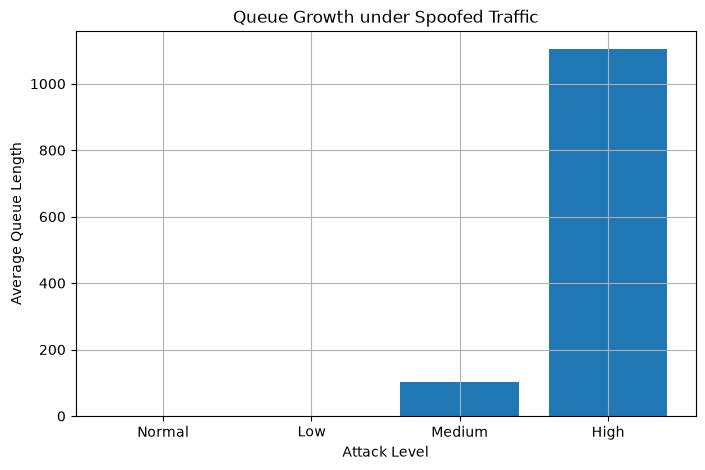

In [61]:
# Queue Length
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Queue_Packets"]
)

plt.xlabel("Attack Level")

plt.ylabel("Average Queue Length")

plt.title("Queue Growth under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_queue_length.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

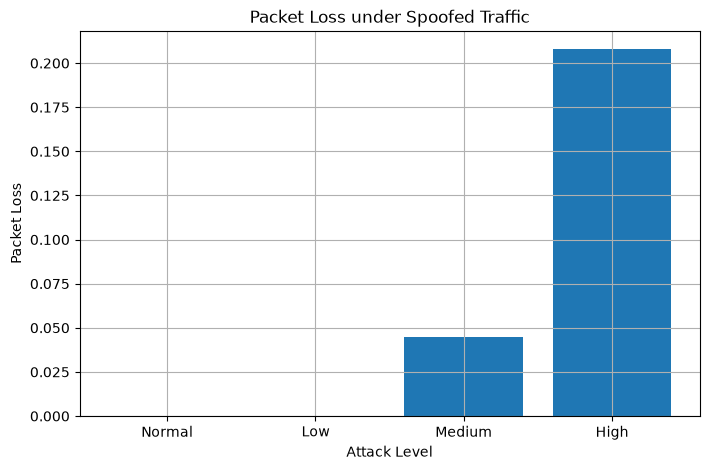

In [62]:
# Packet Loss
plt.figure(figsize=(8,5))

plt.bar(
    impact_results["Attack_Level"],
    impact_results["Avg_Packet_Loss"]
)

plt.xlabel("Attack Level")

plt.ylabel("Packet Loss")

plt.title("Packet Loss under Spoofed Traffic")

plt.grid(True)

plt.savefig(
    "figures_step8_packet_loss.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [63]:
# Imports
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

import sionna

print("TensorFlow:", tf.__version__)
print("Sionna:", sionna.__version__)

# Import Sionna Modules
from sionna.phy.channel import AWGN
from sionna.phy.mapping import Mapper
from sionna.phy.mapping import Demapper

print("Modules Imported Successfully")

TensorFlow: 2.20.0
Sionna: 2.0.1
Modules Imported Successfully


In [64]:
# Simulation Parameters
NUM_BITS = 10000

SNR_dB = np.arange(0,21,2)

ber = []

# Generate Random Bits
bits = tf.random.uniform(
    [NUM_BITS],
    maxval=2,
    dtype=tf.int32
)

print(bits[:20])

tf.Tensor([0 1 1 0 1 0 0 1 0 1 0 1 1 1 0 1 0 1 0 1], shape=(20,), dtype=int32)


In [65]:
# BPSK Mapping
symbols = 2*tf.cast(bits,tf.float32)-1

print(symbols[:20])

tf.Tensor(
[-1.  1.  1. -1.  1. -1. -1.  1. -1.  1. -1.  1.  1.  1. -1.  1. -1.  1.
 -1.  1.], shape=(20,), dtype=float32)


In [66]:
print("SNR_dB:", SNR_dB)
print("Length of SNR_dB:", len(SNR_dB))

print("BER:", ber)
print("Length of BER:", len(ber))
print(ber)

SNR_dB: [ 0  2  4  6  8 10 12 14 16 18 20]
Length of SNR_dB: 11
BER: []
Length of BER: 0
[]


In [67]:
# AWGN Channel
ber = []
for snr in SNR_dB:

    sigma = np.sqrt(1/(2*10**(snr/10)))

    noise = sigma*tf.random.normal(symbols.shape)

    rx = symbols+noise

    detected=tf.cast(rx>0,tf.int32)

    errors=tf.reduce_sum(
        tf.cast(
            detected!=bits,
            tf.int32
        )
    )

    ber.append(errors.numpy()/NUM_BITS)

In [68]:
print(ber)
len(ber)

[np.float64(0.0846), np.float64(0.0382), np.float64(0.0116), np.float64(0.003), np.float64(0.0001), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)]


11

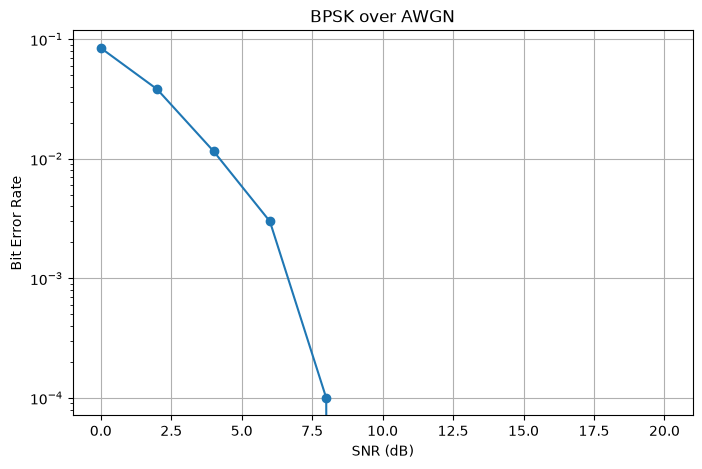

In [69]:
SNR_dB = np.arange(0,21,2)
# BER Curve
plt.figure(figsize=(8,5))

plt.semilogy(
    SNR_dB,
    ber,
    marker='o'
)

plt.grid(True)

plt.xlabel("SNR (dB)")

plt.ylabel("Bit Error Rate")

plt.title("BPSK over AWGN")

plt.savefig(
    "figures_step9_ber_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [70]:
import sionna

print(dir(sionna))
print("Sionna Version:", sionna.__version__)

['ModuleType', '__builtins__', '__cached__', '__doc__', '__file__', '__getattr__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'importlib', 'phy', 'pkgutil']
Sionna Version: 2.0.1


In [71]:
import pkgutil
import sionna

print("Available Sionna Modules\n")

for module in pkgutil.iter_modules(sionna.__path__):
    print(module.name)

Available Sionna Modules

phy
rt
sys


In [72]:
import sionna.phy

print(dir(sionna.phy))

['ALPHA_MAX', 'BOLTZMANN_CONSTANT', 'Block', 'DIELECTRIC_PERMITTIVITY_VACUUM', 'H', 'Object', 'PI', 'Precision', 'SPEED_OF_LIGHT', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'block', 'channel', 'config', 'constants', 'dtypes', 'fec', 'mapping', 'mimo', 'nr', 'object', 'ofdm', 'scipy', 'signal', 'utils']


In [73]:
import pkgutil
import sionna.phy

print("Available PHY Packages\n")

for module in pkgutil.iter_modules(sionna.phy.__path__):
    print(module.name)

Available PHY Packages

block
channel
config
constants
fec
mapping
mimo
nr
object
ofdm
signal
utils


In [74]:
import sionna.phy.channel

print(dir(sionna.phy.channel))

import sionna.phy.ofdm

print(dir(sionna.phy.ofdm))

import sionna.phy.channel as ch

print(dir(ch))

import sionna.phy.ofdm as ofdm

print(dir(ofdm))


['AWGN', 'ApplyFlatFadingChannel', 'ApplyOFDMChannel', 'ApplyTimeChannel', 'BinaryErasureChannel', 'BinaryMemorylessChannel', 'BinarySymmetricChannel', 'BinaryZChannel', 'CIRDataset', 'ChannelModel', 'DEFAULT_L_MIN', 'EDFA', 'FlatFadingChannel', 'GenerateFlatFadingChannel', 'GenerateOFDMChannel', 'GenerateTimeChannel', 'KroneckerModel', 'OFDMChannel', 'PerColumnModel', 'RayleighBlockFading', 'SSFM', 'SpatialCorrelation', 'TimeChannel', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', 'apply_ofdm_channel', 'apply_time_channel', 'awgn', 'channel_model', 'cir_dataset', 'cir_to_ofdm_channel', 'cir_to_time_channel', 'constants', 'deg_2_rad', 'discrete_channel', 'drop_uts_in_sector', 'exp_corr_mat', 'flat_fading_channel', 'gen_single_sector_topology', 'gen_single_sector_topology_interferers', 'generate_ofdm_channel', 'generate_time_channel', 'generate_uts_topology', 'ofdm_channel', 'one_ring_corr_mat', 'optical', 'rad_2_deg

In [75]:
# ======================================================
# STEP 10 - Sionna PHY Integration
# Small-Scale Fading
# ======================================================

import tensorflow as tf
import numpy as np

np.random.seed(42)
tf.random.set_seed(42)

num_users = len(user_positions)

In [76]:
# Rayleigh fading coefficient

# Real part
real = tf.random.normal([num_users], dtype=tf.float32)

# Imaginary part
imag = tf.random.normal([num_users], dtype=tf.float32)

# Create complex channel coefficients
h = tf.complex(real, imag) / tf.cast(tf.sqrt(2.0), tf.complex64)

print(h[:10])

tf.Tensor(
[ 0.23155521+5.9555773e-02j -0.59582645-6.0875088e-01j
  0.22587374+2.6737338e-01j -0.9952895 -3.6743204e-03j
 -1.6886133 -3.4968692e-01j -0.7348592 +4.3686414e-01j
 -0.39408705-2.3392540e-01j  0.38163048-9.7869278e-04j
  1.2016801 -2.9962525e-01j  0.204309  -9.8090470e-01j], shape=(10,), dtype=complex64)


In [77]:
# Channel Power Gain
channel_gain = tf.abs(h)**2

channel_gain = channel_gain.numpy()

print(channel_gain[:10])

[0.0571647  0.7255867  0.12250747 0.9906146  2.973696   0.7308683
 0.2100257  0.14564276 1.5338105  1.003916  ]


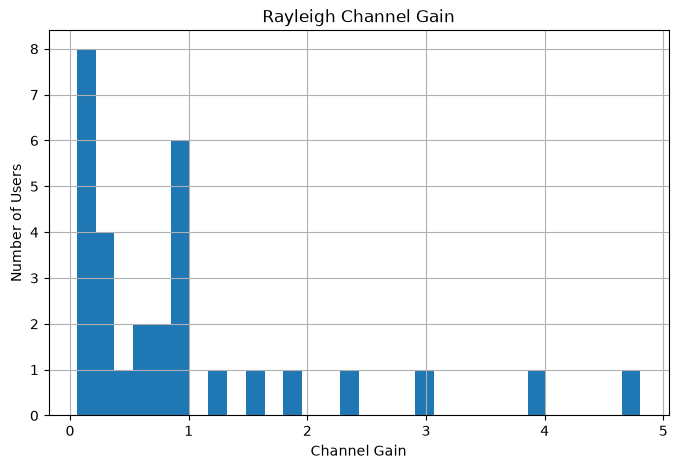

In [78]:
# Plot the Fading Distribution
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(channel_gain,
         bins=30)

plt.xlabel("Channel Gain")

plt.ylabel("Number of Users")

plt.title("Rayleigh Channel Gain")

plt.grid(True)

plt.savefig(
    "figures_step10_channel_gain.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
received_power
channel_gain = channel_gain.reshape(-1, 1)

received_power_fading = received_power + 10*np.log10(channel_gain)

print(received_power_fading[:10])

[[-71.70839376 -80.56521853 -77.80852926]
 [-72.51570818 -72.56381893 -62.22222098]
 [-80.33343324 -76.87502592 -73.03334735]
 [-71.4987721  -69.78788368 -61.87760727]
 [-53.4073807  -65.0774797  -65.40531913]
 [-71.22510917 -73.46185366 -65.5121659 ]
 [-65.87543072 -72.09485235 -71.5747803 ]
 [-70.0733492  -74.77174441 -79.16601466]
 [-68.1124638  -65.13167719 -58.70799273]
 [-65.25107391 -69.17156197 -61.3452952 ]]


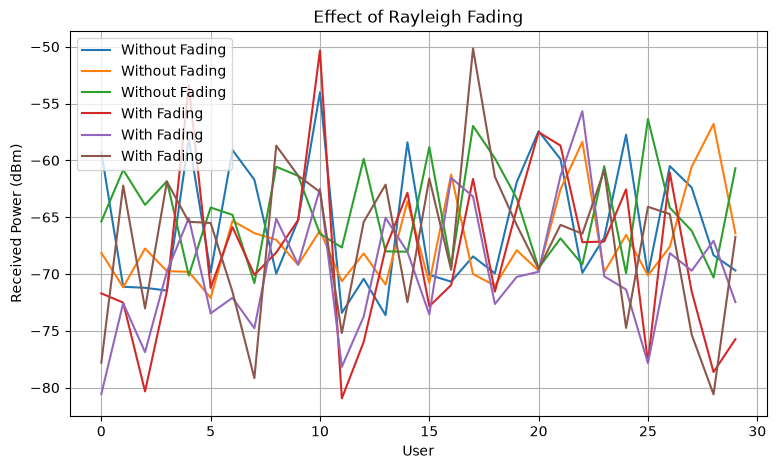

In [80]:
# Plot the Difference
plt.figure(figsize=(9,5))

plt.plot(received_power,
         label="Without Fading")

plt.plot(received_power_fading,
         label="With Fading")

plt.xlabel("User")

plt.ylabel("Received Power (dBm)")

plt.title("Effect of Rayleigh Fading")

plt.legend()

plt.grid(True)

plt.savefig(
    "figures_step10_received_power_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [81]:
# Recalculate SINR
received_power_mW = 10**(received_power_fading/10)

noise_power = 1e-10

sinr = received_power_mW / noise_power

sinr_dB = 10*np.log10(sinr)

print(sinr_dB[:10])

[[28.29160624 19.43478147 22.19147074]
 [27.48429182 27.43618107 37.77777902]
 [19.66656676 23.12497408 26.96665265]
 [28.5012279  30.21211632 38.12239273]
 [46.5926193  34.9225203  34.59468087]
 [28.77489083 26.53814634 34.4878341 ]
 [34.12456928 27.90514765 28.4252197 ]
 [29.9266508  25.22825559 20.83398534]
 [31.8875362  34.86832281 41.29200727]
 [34.74892609 30.82843803 38.6547048 ]]


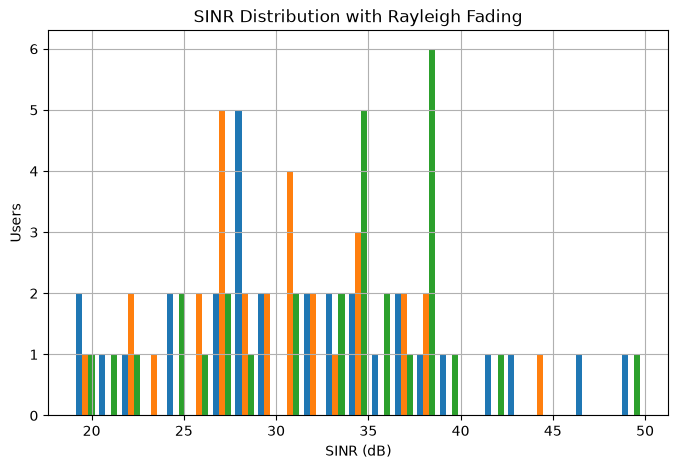

In [82]:
# Compare SINR
plt.figure(figsize=(8,5))

plt.hist(sinr_dB,
         bins=25)

plt.xlabel("SINR (dB)")

plt.ylabel("Users")

plt.title("SINR Distribution with Rayleigh Fading")

plt.grid(True)

plt.savefig(
    "figures_step10_sinr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [83]:
# =====================================================
# STEP 11 - Beamforming
# =====================================================

beamforming_gain_dB = 6

print("Beamforming Gain:", beamforming_gain_dB, "dB")

received_power_beamforming = received_power_fading + beamforming_gain_dB

print(received_power_beamforming[:5])
print(received_power_fading.shape)

Beamforming Gain: 6 dB
[[-65.70839376 -74.56521853 -71.80852926]
 [-66.51570818 -66.56381893 -56.22222098]
 [-74.33343324 -70.87502592 -67.03334735]
 [-65.4987721  -63.78788368 -55.87760727]
 [-47.4073807  -59.0774797  -59.40531913]]
(30, 3)


In [84]:
# Calculate New SINR
received_power_mW = 10 ** (received_power_beamforming / 10)
# Assume:
noise_power_mW = 1e-10

sinr_beam = received_power_mW / noise_power_mW

sinr_beam_dB = 10 * np.log10(sinr_beam)

In [85]:
# Compare Average SINR
print("Average SINR without Beamforming:")

print(np.mean(sinr_dB))

print()

print("Average SINR with Beamforming:")

print(np.mean(sinr_beam_dB))

Average SINR without Beamforming:
31.65772098482415

Average SINR with Beamforming:
37.65772098482415


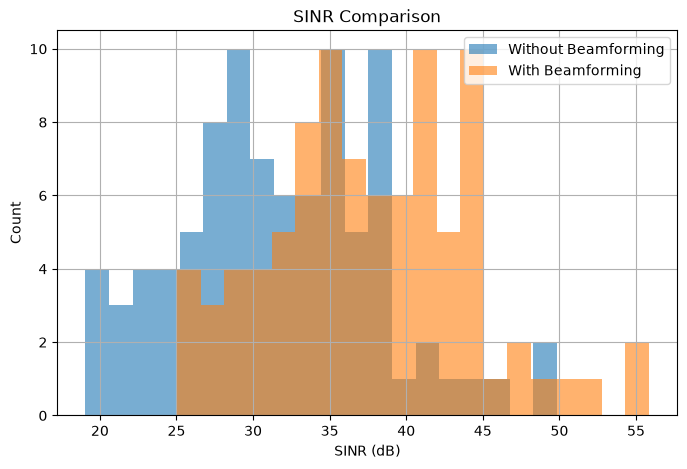

In [86]:
# Plot the Comparison
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(
    sinr_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="Without Beamforming"
)

plt.hist(
    sinr_beam_dB.flatten(),
    bins=20,
    alpha=0.6,
    label="With Beamforming"
)

plt.xlabel("SINR (dB)")
plt.ylabel("Count")
plt.title("SINR Comparison")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_sinr_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [87]:
import numpy as np

# Check the shape first
print("Received power shape:", received_power_beamforming.shape)

# Assign each user to the BS with the highest received power
assignments_beamforming = np.argmax(
    received_power_beamforming,
    axis=1
)

print("User assignments:")
print(assignments_beamforming)

Received power shape: (30, 3)
User assignments:
[0 2 2 2 0 2 0 0 2 2 0 2 2 2 0 2 1 2 2 0 0 0 1 2 0 2 0 1 1 2]


In [88]:
# Count Users Per Base Station
num_bs = received_power_beamforming.shape[1]

users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

BS 1: 11 users
BS 2: 4 users
BS 3: 15 users


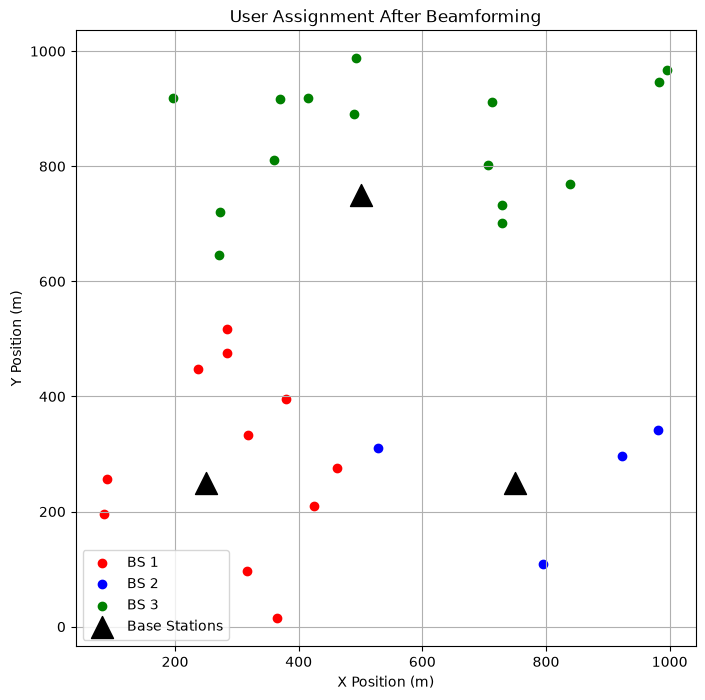

In [89]:
# Visualize User Assignment
colors = ["red", "blue", "green"]

plt.figure(figsize=(8,8))

for bs in range(num_bs):

    users = user_positions[
        assignments_beamforming == bs
    ]

    plt.scatter(
        users[:,0],
        users[:,1],
        color=colors[bs],
        label=f"BS {bs+1}"
    )

plt.scatter(
    bs_positions[:,0],
    bs_positions[:,1],
    marker="^",
    s=250,
    color="black",
    label="Base Stations"
)

plt.xlabel("X Position (m)")
plt.ylabel("Y Position (m)")
plt.title("User Assignment After Beamforming")

plt.legend()
plt.grid(True)

plt.savefig(
    "figures_step11_user_assignment_beamforming.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [90]:
# =======================================================
# STEP 12 - Base Station Load Analysis and Visualization
# =======================================================

# STEP 12.1 - Base Station Load Analysis

num_bs = received_power_beamforming.shape[1]

# Number of users connected to each BS
users_per_bs = np.bincount(
    assignments_beamforming,
    minlength=num_bs
)

print("===== BASE STATION LOAD =====")

for bs in range(num_bs):
    print(f"BS {bs+1}: {users_per_bs[bs]} users")

print("\nTotal Users:", np.sum(users_per_bs))

===== BASE STATION LOAD =====
BS 1: 11 users
BS 2: 4 users
BS 3: 15 users

Total Users: 30


In [91]:
# STEP 12.2 - Load Percentage

load_percentage = (
    users_per_bs / np.sum(users_per_bs)
) * 100

print("===== BASE STATION LOAD PERCENTAGE =====")

for bs in range(num_bs):
    print(
        f"BS {bs+1}: "
        f"{load_percentage[bs]:.2f}% "
        f"({users_per_bs[bs]} users)"
    )

===== BASE STATION LOAD PERCENTAGE =====
BS 1: 36.67% (11 users)
BS 2: 13.33% (4 users)
BS 3: 50.00% (15 users)


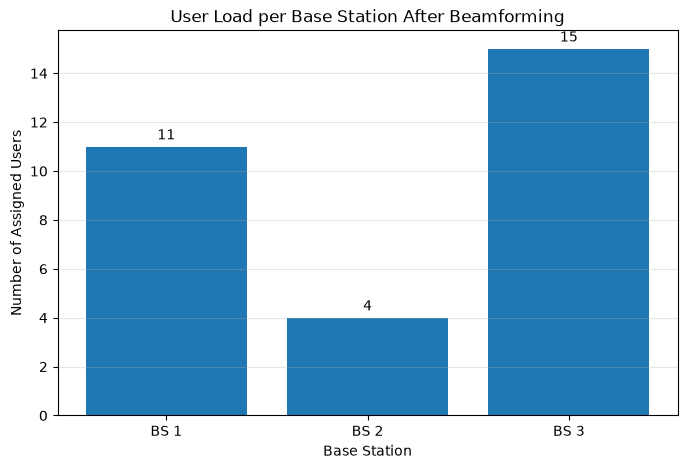

In [94]:
import matplotlib.pyplot as plt
import numpy as np

# STEP 12.3 - Plot Base Station Load

bs_labels = [
    f"BS {i+1}"
    for i in range(num_bs)
]

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    users_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Number of Assigned Users")
plt.title("User Load per Base Station After Beamforming")

# Add values above bars
for i, value in enumerate(users_per_bs):
    plt.text(
        i,
        value + 0.3,
        str(value),
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

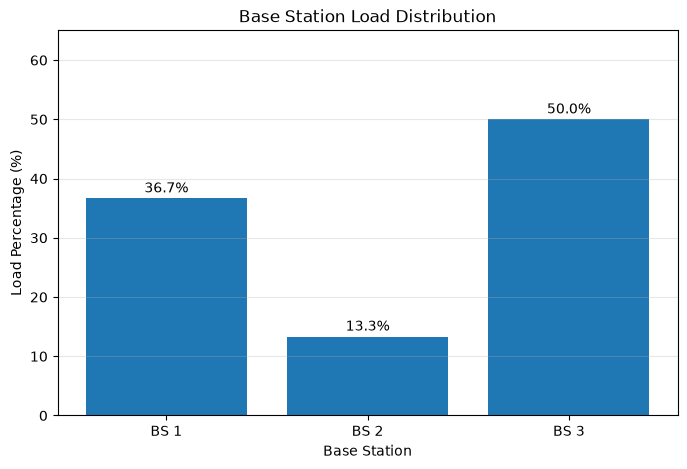

In [93]:
# STEP 12.4 - Base Station Load Percentage

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    load_percentage
)

plt.xlabel("Base Station")
plt.ylabel("Load Percentage (%)")
plt.title("Base Station Load Distribution")

for i, value in enumerate(load_percentage):
    plt.text(
        i,
        value + 1,
        f"{value:.1f}%",
        ha="center"
    )

plt.ylim(
    0,
    max(load_percentage) + 15
)

plt.grid(axis="y", alpha=0.3)

plt.show()

In [95]:
# ===================================================
# STEP 13 - Realistic Legitimate Traffic Generation
# ===================================================

# STEP 13.1 - Traffic Generation Setup

import numpy as np
import matplotlib.pyplot as plt

# Fixed seed for reproducible traffic generation
np.random.seed(42)

num_users = len(assignments_beamforming)

print("Number of users:", num_users)

Number of users: 30


In [96]:
# STEP 13.2 - Generate Realistic User Traffic

np.random.seed(100)

# Randomly assign traffic types
traffic_type = np.random.choice(
    ["Low", "Medium", "High"],
    size=num_users,
    p=[0.4, 0.4, 0.2]
)

# Create traffic demand in Mbps
user_traffic = np.zeros(num_users)

for i in range(num_users):

    if traffic_type[i] == "Low":
        user_traffic[i] = np.random.uniform(0.5, 2.0)

    elif traffic_type[i] == "Medium":
        user_traffic[i] = np.random.uniform(2.0, 8.0)

    elif traffic_type[i] == "High":
        user_traffic[i] = np.random.uniform(8.0, 20.0)

print("Traffic generated successfully.")
print("\nFirst 10 users:")

for i in range(min(10, num_users)):
    print(
        f"User {i+1}: "
        f"{traffic_type[i]} traffic, "
        f"{user_traffic[i]:.2f} Mbps"
    )

Traffic generated successfully.

First 10 users:
User 1: Medium traffic, 5.59 Mbps
User 2: Low traffic, 1.41 Mbps
User 3: Medium traffic, 2.63 Mbps
User 4: High traffic, 12.58 Mbps
User 5: Low traffic, 0.55 Mbps
User 6: Low traffic, 1.84 Mbps
User 7: Medium traffic, 7.89 Mbps
User 8: High traffic, 8.72 Mbps
User 9: Low traffic, 1.84 Mbps
User 10: Medium traffic, 5.46 Mbps


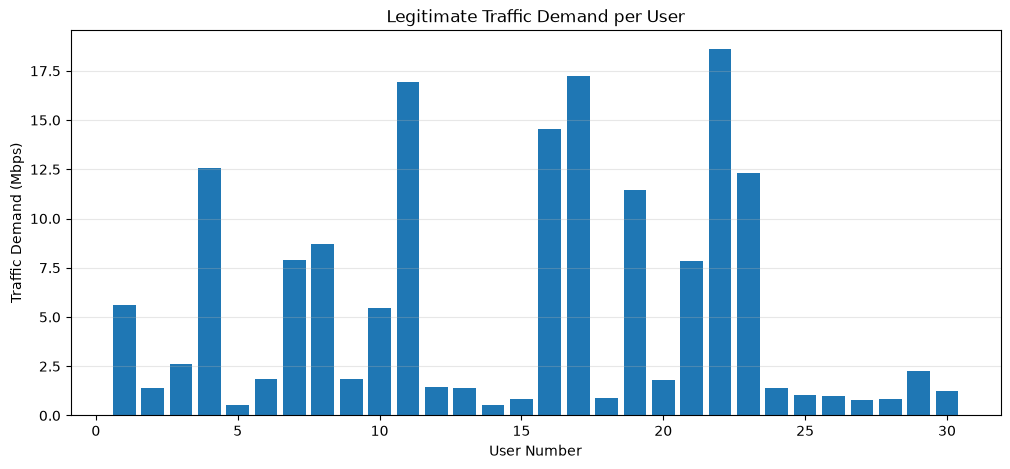

In [97]:
# STEP 13.3 - Plot Traffic Demand per User

plt.figure(figsize=(12, 5))

plt.bar(
    np.arange(1, num_users + 1),
    user_traffic
)

plt.xlabel("User Number")
plt.ylabel("Traffic Demand (Mbps)")
plt.title("Legitimate Traffic Demand per User")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [98]:
assignments_beamforming

# STEP 13.4 - Calculate Traffic Load per Base Station

traffic_per_bs = np.zeros(num_bs)

for bs in range(num_bs):

    # Get users assigned to this BS
    bs_users = (
        assignments_beamforming == bs
    )

    # Sum traffic from assigned users
    traffic_per_bs[bs] = np.sum(
        user_traffic[bs_users]
    )

print("===== LEGITIMATE TRAFFIC PER BASE STATION =====")

for bs in range(num_bs):

    print(
        f"BS {bs+1}: "
        f"{traffic_per_bs[bs]:.2f} Mbps"
    )

print(
    "\nTotal Network Traffic:",
    f"{np.sum(traffic_per_bs):.2f} Mbps"
)

===== LEGITIMATE TRAFFIC PER BASE STATION =====
BS 1: 70.52 Mbps
BS 2: 32.67 Mbps
BS 3: 59.61 Mbps

Total Network Traffic: 162.80 Mbps


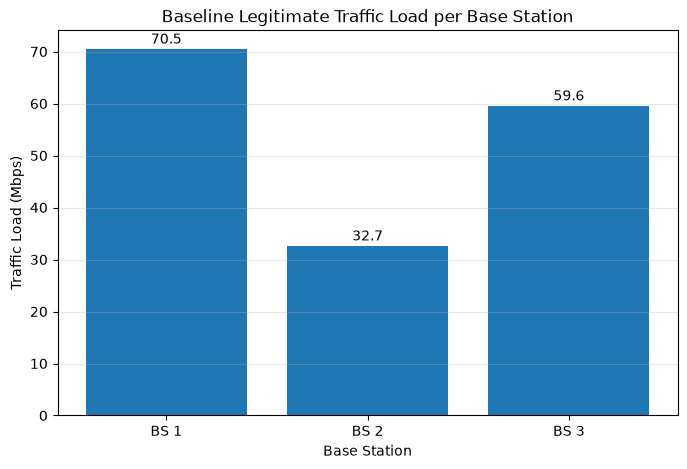

In [99]:
# STEP 13.5 - Visualize Traffic Load per Base Station

plt.figure(figsize=(8, 5))

plt.bar(
    bs_labels,
    traffic_per_bs
)

plt.xlabel("Base Station")
plt.ylabel("Traffic Load (Mbps)")
plt.title("Baseline Legitimate Traffic Load per Base Station")

# Add traffic values above bars
for i, value in enumerate(traffic_per_bs):

    plt.text(
        i,
        value + 1,
        f"{value:.1f}",
        ha="center"
    )

plt.grid(axis="y", alpha=0.3)

plt.show()

In [100]:
# STEP 13.6 - User Traffic Summary

import pandas as pd

traffic_summary = pd.DataFrame({
    "User": np.arange(1, num_users + 1),
    "Traffic Type": traffic_type,
    "Traffic Demand (Mbps)": np.round(user_traffic, 2),
    "Assigned BS": assignments_beamforming + 1
})

traffic_summary

,User,Traffic Type,Traffic Demand (Mbps),Assigned BS
0,1,Medium,5.59,1
1,2,Low,1.41,3
2,3,Medium,2.63,3
3,4,High,12.58,3
4,5,Low,0.55,1
5,6,Low,1.84,3
6,7,Medium,7.89,1
7,8,High,8.72,1
8,9,Low,1.84,3
9,10,Medium,5.46,3
